# **Grupo 3: Mountain Car para comparativa de modelos aproximados**

Autor:

- Miguel Ángel Ortiz Peñaranda


## Introducción

El objetivo de este notebook es establecer una comparativa en cuanto a desempeño para distintos agentes de aprendizaje por refuerzo que siguen el modelo **aproximado**. A diferencia de los modelos tabulares, que utilizan una tabla que asocia cada posible estado a un valor para cada posible acción en ese estado, los modelos aproximados realizan el aprendizaje de **una función de valor**, $v(s)$, que puede corresponderse, por ejemplo, con una función lineal, o una red neuronal, y que se asocia con una serie de pesos que pondera a cada característica que identifica a ese estado. De esta forma, dado un estado, es posible determinar que acciones puede realizar el agente, sin tener que almacenar una tabla infinitamente grande que contemplase todas las casuísticas, lo cual no sería posible.

Los modelos aproximados, al igual que los tabulares, presentan una serie de ventajas:

- Pueden estimar valores para estados nunca vistos a partir de experiencias previas similares, lo que supone que el agente es capaz de generalizar.
- Son escalables, es decir, permiten trabajar con conjuntos de estados muy grandes o continuos donde una tabla sería inviable.
- Solo almacenan los parámetros del modelo (pesos), en lugar de una entrada para cada estado o estado-acción, lo cual supone un consumo de memoria generalmente inferior a los modelos tabulares.

También presentan una serie de desventajas con respecto a los modelos tabulares:

- A diferencia de muchos métodos tabulares, pueden divergir o volverse inestables durante el entrenamiento, con lo que no garantizan su convergencia.
- Requieren elegir y ajustar modelos, hiperparámetros y técnicas de entrenamiento, lo que complejiza su arquitectura.
- Al generalizar, una actualización puede afectar a muchos estados simultáneamente, y potencialmente introducir errores en regiones que antes estaban bien estimadas.

## Descripción del entorno

En este notebook en particular, nos centraremos en el problema de _gymnasium_ **Mountain Car**, que trata de guiar un agente para que, empezando en un lugar aleatorio en el fondo de un valle, acabe subiendo una colina a su derecha hasta llegar a su cima. El agente debe elegir como se mueve y qué aceleración aplica para acabar en su objetivo.

El coche solo se mueve a lo largo de un eje. Sabiendo esto, nos encontramos con dos variables que definen la situación del agente (su espacio de estados). Podemos ver como, al emplear rangos de números reales, constituye una representación continua de estas componentes:

- Posición del coche en torno al eje X, en metros, cuyo valor mínimo es -1.2, y su valor máximo es de 0.6.
- Velocidad del coche, en m/s, cuyo valor mínimo es de -0.07, y su valor máximo es de 0.07.

En la siguiente tabla aparecen representadas con sus valores máximo y mínimo.

| Número | Observación                          | Mínimo | Máximo | Unidad        |
|--------|--------------------------------------|--------|--------|---------------|
| 0      | Posición del coche en el eje x      | -1.2   | 0.6    | posición (m)  |
| 1      | Velocidad del coche                 | -0.07  | 0.07   | velocidad (v) |

El espacio de acciones queda comprendido por tres posibles acciones discretas:
- 0: Acelerar a la izquierda
- 1: No acelerar
- 2: Acelerar a la derecha

Dado esto, tenemos que, dada una posición en el instante $t$, y una velocidad en ese mismo instance, su posición y velocidad en el instante siguiente en el tiempo, $t+1$ resultan como:


$velocity_{t+1} = velocity_t + force * self.power - 0.0025 * cos(3 * position_t)$

$position_{t+1} = position_t + velocity_{t+1}$

Donde la fuerza es la acción que hemos comentado anteriormente y power es la constante que también hemos mencionado. Las colisiones suponen que la velocidad se fije a 0 cuando se colisiona con los muros, que están en los límites inferior (-1.2) y superior (0.6) del rango de la posición.

El objetivo del episodio se cumple cuando el coche llega a una posición mayor o igual a 0.45, que se corresponde con la cima de la colina. El episodio se truncará si la duración excede 999 _steps_.

En cuanto a las recompensas, se obtendrá una recompensa negativa de -1 por cada paso de tiempo que transcurra sin que el agente llegue a la colina.


## Metodología de trabajo

Se propone una metodología de trabajo en la que se va a probar con distintas variantes de los agentes aproximados el desempeño para cada agente. Siendo así, seguiremos los siguientes pasos:

1. Para cada entorno, entrenaremos todos los tipos de agentes aproximados comprendidos.
2. Se obtendrán una serie de estadísticas que nos permitan graficar la recompensa obtenida por cada agente a lo largo del tiempo, y la evolución de la longitud de cada episodio, en _steps_.
3. Se comparará la mejor recompensa obtenida por el agente con el resto de agentes, y la mejor longitud de episodio que es capaz de conseguir con la del resto de agentes y con la óptima.
4. Se pomediarán los resultados obtenidos para cada entorno, para cada agente.
5. Se darán unas conclusiones finales que indiquen qué algoritmo o algoritmos se considera que presentan un mejor comportamiento.

## 1. Preparación del Entorno

La preparación consta de las siguientes partes:
- **Instalación de Dependencias**: Se instalan las librerías necesarias para utilizar el entorno `gymnasium` para la simulación, con el objetivo de crear un ambiente controlado para que el agente pueda interactuar.
- **Importación de Librerías**: Se importan las bibliotecas necesarias como `numpy` para el manejo de matrices y `matplotlib` para la visualización de los resultados.

- **Importación del Entorno "MountainCar"**.

- **Importación de las implementaciones de los agentes**:
Se importarán las implementaciones existentes bajo src/ de los agentes aproximados que deseamos comparar
  - Deep Q-Learning
  - Sarsa Semi-Gradient

- **Discretización del espacio de observaciones del entorno (para SARSA Semi-Gradient)**
  - Utilizando la técnica de Tile Coding

- **Creación del wrapper para recompensas (para SARSA Deep Q-Learning)**
  - Para alterar las recompensas que da el entorno

Dependencias adicionales para poder ser ejecutado en colab.

In [1]:
!pip install 'gym[box2d]==0.20.0'

## Instalación de paquetes adicionales para uso en colab
!apt-get update
!apt install swig
!pip install gymnasium[box2d]

Se utiliza este código para clonar el repositorio y fijar en path de cara a poder ejecutarlo en colab.

In [ ]:
!rm -r exml-ortizpenaranda/
!git clone https://github.com/miguelangelortizpenaranda/exml-ortizpenaranda.git
!cd exml-ortizpenaranda/

In [ ]:
#@title Importamos todas las clases y funciones
import sys


# Añadir los directorios fuentes al path de Python
sys.path.append('/content/exml-ortizpenaranda/entornos_complejos/src/eml_complex_environments')
sys.path.append('src/eml_complex_environments')

# Verificar que se han añadido correctamente
print(sys.path)


In [35]:
from tqdm import tqdm
import gymnasium as gym
from IPython.core.display import HTML
import base64
import imageio

from agents import *
from util import *

A continuación vamos a crear dos instancias del entorno de Mountain Car. Fijamos el parámetro de `goal_velocity`, que determina la velocidad mínima que debe llevar el coche cuando llegue al objetivo para que se acepte el resultado.

In [3]:
name = 'MountainCar-v0'
env = gym.make(name, render_mode="rgb_array")
env.reset()

(array([-0.42296076,  0.        ], dtype=float32), {})

Discretizamos el espacio de estados de este entorno utilizando la técnica de Tile Coding, que realiza un mapeo de los posibles valores que pueden tener las dos componentes continuas (posición, velocidad), que puede tener el coche, a una serie de "casillas" que comprenden cada una a una partición del rango donde se representa cada componente.

Recordemos que nuestro objetivo es aproximar una función de valor $q(s, a)$. De esta forma, haciendo discretizado el espacio de s, tenemos que, para cada acción a contemplar, la función de aproximación de q(s,a), tendrá tantos pesos como número de _tiles_ totales existan en todos los _tilings_. En cada estado, solo se activarán una serie de _tiles_, correspondientes a los valores de las componentes de ese estado, lo que significa que solo se actualizan los pesos correspondientes a esos _tiles_.

Usando esta técnica, se va a crear un wrapper del entorno, `TileCodedEnvironment`, que hereda de `ObservationWrapper` de gymnasium, y que realiza una modificación sobre el estado, u "observación" del entorno original cada vez que se consulta. De esta forma, se pasa de devolver un estado continuo a su representación discreta usando los _tiles_. Esto nos va a servir para poder calcular los pesos de nuestro algoritmo **Sarsa Semi-Gradient**, que utiliza una función de aproximación lineal.

In [4]:
#Generamos mosaicos (tilings) con varios intervalos por dimensión
tilings = 8  # Número de mosaicos que vamos a utilizar. Mayor número de mosaicos implica mayor granularidad a la hora de realizar la discretización
bins = np.array([20, 20])  # Número de intervalos en cada dimensión (mosaico)
low = env.observation_space.low # Límite inferior de valores para cada dimensión
high = env.observation_space.high # Límite superior de valores para cada dimensión
tile_coded_env = TileCodedEnvironment(env, bins=bins, low=low, high=high, n=tilings) # Creamos el tiler para discretizar el espacio de estados

Tras su creación podemos ver que seguimos teniendo el número de accciones original, pues ya eran discretas, y que tenemos 3200 posibles features para el aproximador lineal (20x20x8).

In [5]:
num_actions = tile_coded_env.env.action_space.n # Número de acciones en el entorno original
print(f'Numero de acciones contempladas: {num_actions}')
total_features = tile_coded_env.n_tilings * np.prod(tile_coded_env.bins) # Número total de características en el aproximador lineal
print(f'Numero de características totales de a función lineal: {total_features}')

Numero de acciones contempladas: 3
Numero de características totales de a función lineal: 3200


Procedemos a observar como, anteriormente, para el entorno original, el espacio de estados estaba compuesto por dos componentes contínuas, y actualmente está compuesto por las componentes MultiDiscrete que hemos definido en la configuración del TileCoder.

In [6]:
print(f"El espacio de observaciones original es: {env.observation_space}, \n\
Un estado para este espacio original es: {env.step(env.action_space.sample())}")
print(f"\nEl espacio de estados modificado es: {tile_coded_env.observation_space}. Mosaicos: {tile_coded_env.n_tilings} \n\
Un estado para este nuevo espacio es: {tile_coded_env.step(tile_coded_env.action_space.sample())[0]} \n\
Cada pareja es la 'celda' correspondiente a cada mosaico")
print(f"Las caracterísiticas observadas han sido {tile_coded_env.last_active_features} sobre {np.prod(tile_coded_env.bins)*tile_coded_env.n_tilings} parámetros")

El espacio de observaciones original es: Box([-1.2  -0.07], [0.6  0.07], (2,), float32), 
Un estado para este espacio original es: (array([-0.42470413, -0.00174337], dtype=float32), -1.0, False, False, {})

El espacio de estados modificado es: MultiDiscrete([20 20 20 20 20 20 20 20 20 20 20 20 20 20 20 20]). Mosaicos: 8 
Un estado para este nuevo espacio es: [(np.int64(8), np.int64(9)), (np.int64(8), np.int64(9)), (np.int64(8), np.int64(8)), (np.int64(8), np.int64(9)), (np.int64(8), np.int64(9)), (np.int64(8), np.int64(8)), (np.int64(8), np.int64(9)), (np.int64(7), np.int64(8))] 
Cada pareja es la 'celda' correspondiente a cada mosaico
Las caracterísiticas observadas han sido [np.int64(169), np.int64(569), np.int64(968), np.int64(1369), np.int64(1769), np.int64(2168), np.int64(2569), np.int64(2948)] sobre 3200 parámetros


A continuación, vamos a crear otro wrapper del entorno original. En este caso, utilizamos `MountainCarRewardEnvironment`, que extiende directamente de `gymnasium.Wrapper`, que modifica directamente el método _step_, para alterar la recompensa que nos es dada. Durante el entrenamiento de las redes neuronales usando **Deep Q-Learning**, vimos que presentaban dificultades a la hora de aprender a resolver el problema con las recompensas que se daban originalmente (que eran sencillamente un descuento de -1 por paso de tiempo). El agente no lograba resolver el problema y llegar a la cima de la colina solo con esa información, probablemente porque no lograba saber si una acción con respecto a otra era buena o mala, puesto que todas al final eran penalizadas de la misma forma. Necesitábamos una recompensa más rica, que fuera capaz de indicar al agente como de bueno era realizar una acción concreta dada su posición.

De esta forma, modificando la recompensa que se da originalmente por otra que tenga en cuenta, no solo el descuento por tiempo, sino la posición y la velocidad (en este caso, energía cinética) del agente en ese instante, hemos podido comprobar como se realiza un aprendizaje mucho más efectivo. El nuevo patrón de recompensa para el `MountainCarRewardEnvironment` sigue la siguiente relación:

$$RecompensaModificada = RecompensaOriginal + [posición + 0.5] + speed^2 * 10$$

Siendo 0.5 la posición final en $x$ donde se sitúa el coche, de forma que se bonifique al subir cualquiera de las pendientes, y se penalice el quedarse al fondo de la colina, y $speed^2*10$ se trata sencillamente de la velocidad que tenga, magnificada de forma que también se bonifique el hecho de llevar cierta velocidad. De esta forma, se sigue aplicando un descuento por tiempo, pero el agente es capaz de llegar a la meta.

In [7]:
adapted_reward_env = MountainCarRewardEnvironment(env)

Establecemos también una semilla aleatoria y se la fijamos a _numpy_, de forma que, cuando intentemos obtener algún número aleatorio, obtengamos los mismos de forma consistente
entre distintas ejecuciones del programa, en distintos equipos.

In [8]:
random_seed = 123
np.random.seed(random_seed)

## 2. Diseño de los agentes y algoritmo de entrenamiento

Cada agente queda representado por una clase distinta, que implementa el algoritmo que sigue para realizar el proceso de aprendizaje y la toma de decisiones. Todos los agentes heredan de la clase abstracta **ApproximateAgent**, a diferencia de los agentes tabulares que heredaban de la clase **TabularAgent**, que presenta los siguientes métodos:

- `get_action`: En base al estado actual en el que se encuentre el agente, toma una acción usando una política. La política que vamos a utilizar cuando el agente está aprendiendo es una política epsilon-greedy, que permite que se "explote" la mejor acción conocida la mayoría del tiempo, pero permite "explorar" nuevas acciones con una probabilidad determinada. Esta política se deriva de una epsilon-soft, donde varias acciones pueden tener una probabilidad determinada de ser elegidas. Si establecemos que se utilice epsilon-decay, esta probabilidad de explorar irá decreciendo conforme nos acerquemos al final del entrenamiento del agente. Cuando el agente haya sido entrenado, utilizaremos una política puramente greedy, que elegirá siempre la mejor acción conocida para cada estado.
- `on_episode_step`: Este método será llamado para cada agente cuando se realice un cambio de estado en un episodio (el agente realice una acción). Como, en base a esa acción, obtenemos una recompensa y un nuevo estado, podemos usar esos valores para que cada agente actualice su estado interno.
- `on_episode_finished`: Se llamará a este método cuando el agente haya finalizado un episodio, ya sea porque ha llegado al objetivo o porque ha terminado abruptamente. Cada agente realizará las acciones pertinentes en este caso.

En este caso, hemos contemplado dos implementaciones para los agentes:

- **SARSA Semi-Gradient**: Este método, On-Policy, funciona de forma similar al SARSA original, pero utiliza, en lugar de una tabla que guarda el valor para cada estado-acción, una función de aproximación lineal $q(s, a)$ que, dados unos pesos que se van aprendiendo conforme al entrenamiento, es capaz de dar el valor q para un estado, previamente discretizado usando el _TileEncoder_. Se utilizará, por tanto, el valor de retorno actual, y valor de retorno esperado en un estado y acción futuras, para calcular el error (Diferencias temporales) y actualizar los pesos que se utilizan en la función de aproximación (cuando en SARSA tradicional se actualizaba la tabla).
- **Deep Q-Learning**: Este método, Off-Policy, queda conformado por dos redes neuronales. Una se utilizará para predecir los retornos de la política de comportamiento y la otro para obtener los de la política objetivo. En cada nuevo paso, se utilizará la red de la política de comportamiento para decidir la acción a realizar, y cuando se llene el _replay buffer_, es decir, una "memoria" de los pasos que hemos ido dando, se utilizará la red objetivo para calcular los retornos esperados, calcular las diferencias temporales, y actualizar los pesos de la red original. Cada cierta cantidad de pasos se "congela" la red de comportamiento en la red objetivo, en aras de actualizar sus pesos.


El siguiente método `run_agent` recibe como parámetro la clase genérica de tipo `ApproximateAgent`, de forma que sea agnóstico a la implementación del agente que se va a entrenar. Realizará las siguientes acciones:

- Iterará por un número especificado de episodios en el entorno especificado, en cada cual el agente intentará resolver el problema y llegar al objetivo.
- Para cada episodio puede darse el caso de que se termine de forma natural (porque llega a la cima de la colina), o que haya sido truncado, porque exista un número máximo de pasos, o _steps_, configurados para ese episodio, de forma que el agente no pueda quedarse de forma infinita estancado en el mismo.
- Se calcularán durante el transcurso del entrenamiento las estadísticas de promedio de recompensas acumuladas por episodio, y longitud de cada episodio, de cara a graficar el comportamiento de cada agente

In [9]:

def run_agent(agent, env, num_episodes=5000):
  """
  Entrena al agente especificado, en un entorno concreto, a lo largo de un número de episodios. Obtiene algunas métricas
  que se utilizarán posteriormente para graficar el comportamiento del agente.
  :param agent: Agente que se va a entrenar
  :param env: Entorno de gymnasium en el que se va a entrenar el agente, será el wrapper con tile encoding para SARSA Semi-Gradient, y el wrapper
  con recompensas modificadas para Depp Q-Learning
  :param num_episodes: Número de episodios en los que se va a comprender el entrenamiento
  :return: modelo del agente, lista de recompensas acumuladas, lista de longitud de cada episodio, número de episodios completados correctamente, y promedio de longitud de episodio correcto
  """
  # Para mostrar la evolución en el terminal y algún dato que mostrar
  stats = 0.0
  list_stats = [stats]
  step_display = num_episodes / 10
  lengths = 0.0
  episode_lengths = [lengths]
  n_correct_finished_episodes = 0
  sum_correct_episode_lengths = 0
  avg_correct_episode_length = 0.0

  for t in tqdm(range(num_episodes)):
      current_state, info = env.reset(seed=random_seed + t) # De forma reproducible, se asegura de que cada episodio inicie distinto
      agent.set_initial_state(current_state)
      done = False
      while not done:
          action = agent.get_action(current_state)
          new_state, reward, episode_finished, truncated, info = env.step(action) # Avanzamos un estado en el entorno
          done = episode_finished or truncated
          agent.on_episode_step(new_state, action, reward, t, episode_finished) # El agente actualiza su información dado uun nuevo paso
          current_state = new_state
          # Consideramos que un episodio ha terminado correctamente si no ha sido truncado
          if episode_finished and not truncated:
            n_correct_finished_episodes += 1
            sum_correct_episode_lengths += agent.get_episode_len()

      episode_lengths.append(agent.get_episode_len())
      result_sum = agent.on_episode_finished()

      # Guardamos datos sobre la evolución. Promedio de recompensas
      stats += result_sum
      avg_stat = stats/(t+1)
      list_stats.append(avg_stat)

      current_epsilon = agent.get_current_epsilon()
      # Para mostrar la evolución. Comentar si no se quiere mostrar
      if t % step_display == 0 and t != 0:
          print(f"success: {stats/t}, epsilon: {current_epsilon}")

  if n_correct_finished_episodes > 0:
    avg_correct_episode_length = sum_correct_episode_lengths / n_correct_finished_episodes

  return agent.get_model(), list_stats, episode_lengths, n_correct_finished_episodes, avg_correct_episode_length


Definimos también el método `run_agents` que nos permite hacer lo propio pero para un conjunto de agentes. En un diccionario se almacenará, usando como clave el nombre de cada agente:
- El modelo que han construído los agentes
- La proporción de recompensas para ese agente
- La longitud de cada episodio para ese agente
- El número total de episodios completados correctamente (llegando a la casilla objetivo) por ese agente
- El promedio de la longitud de los episodios terminados correctamente, en _steps_

In [10]:
def run_agents(agents, num_episodes):
    """
    Entrena un conjunto de agentes en un entorno determinado, obteniendo métricas de su desempeño para almacenarlas y más tarde
    devolverlas cuando termine el entrenamiento del conjunto
    :param agents: Conjunto de agentes a entrenar
    :param num_episodes: número de episodios para los cuales se realizará el entrenamiento
    :return: modelos de los agentes, listas de recompensas acumuladas, listas de longitudes de cada episodio, número de episodios completados correctamente, y promedio de longitud de episodio correcto
    """
    agent_models = {}
    agent_stats = {}
    agent_episode_lengths = {}
    agent_correct_finished_episodes = {}
    agent_avg_correct_episode_lengths = {}

    for agent in agents:
        agent_name = agent.get_name()
        agent_env = agent.get_env()
        print(f'\nRunning agent {agent_name}')
        model, list_stats, episode_lengths, n_correct_finished_episodes, avg_correct_episode_length = run_agent(agent, agent_env, num_episodes)
        agent_models[agent_name] = model
        agent_stats[agent_name] = list_stats
        agent_episode_lengths[agent_name] = episode_lengths
        agent_correct_finished_episodes[agent_name] = n_correct_finished_episodes
        agent_avg_correct_episode_lengths[agent_name] = avg_correct_episode_length

    return agent_models, agent_stats, agent_episode_lengths, agent_correct_finished_episodes, agent_avg_correct_episode_lengths

Se define asimismo un método de apoyo, `create_agents`, que nos permita crear todos los agentes que se van a evaluar parametrizados. En un apartado previo, ya hemos definido el funcionamiento de cada uno de los agentes, así que no vamos a volver a desarrollarlo.

Los agentes recibirán como parámetro el factor de decaimiento, para epsilon decay, el factor de descuento del retorno futuro, y un valor para la tasa de aprendizaje para el agente, o como de rápido olvida el agente información antigua para ser reemplazada por nueva información.

In [11]:
def create_agents(decay_factor, discount_factor, learning_rate):
    """
    Crea todos los agentes aproximados para los que se va a realizar el entrenamiento y comparativa. Admite los parámetros con los que se va a probar
    en la experimentación.
    :param decay_factor: Factor de decaimiento para epsilon-decay
    :param discount_factor: Factor de descuento para el retorno futuro (1.0 = no se realiza descuento sobre valor futuro)
    :param learning_rate: Indica la tasa de aprendizaje del agente
    :return: array con todos los agentes parametrizados
    """
    sarsa_semi_gradient = SARSASemiGradient(tile_coded_env, 1.0, discount_factor, learning_rate, random_seed, decay_factor=decay_factor)
    deep_qlearning = DeepQLearning(adapted_reward_env, 1.0, discount_factor, learning_rate, random_seed, decay_factor=decay_factor)
    return [deep_qlearning, sarsa_semi_gradient]


## 3. Ejecución del experimento

En esta sección se va a proceder, dado el algoritmo y los agentes implementados previamente, a evaluar su desempeño en el entorno de Mountain Car.

Vamos a probar todos los agentes con las siguientes variaciones en sus parámetros:

- **decay_factor**= [0.997, 0.999],
- **learning_rate**= [0.0005, 0.001, 0.05],
- **discount_factor**= [0.99, 0.9],

De esta forma podemos observar cómo se comportan los agentes con distintas componentes exploratorias. El uso de epsilon decaimiento supondrá que el algoritmo se volverá más greedy y menos exploratorio por cierto conforme el agente va llegando a los últimos episodios, es decir, explotará únicamente la política aprendida y apenas no explorará, en contraste con al principio del algoritmo, que actuará de forma prácticamente aleatoria.

No nos hemos planteado utilizar un epsilon fijo porque ya pudimos ver en experimentos anteriores como el uso de un epsilon-decaimiento es bastante aconsejable. Utilizaremos directamente un factor que se aplique cada nuevo episodio al epsilon inicial, que será de 1.0, y que propicie su decrecimiento de forma más o menos acentuada.

Dada la ejecución de los agentes para estos parámetros, se visualizará para su comparativa:
- Proporción máxima de recompensas que ha obtenido el agente
- Número total de episodios que han terminado correctamente
- Promedio de longitud de los episodios que han terminado correctamente

Al final de la experimentación promediaremos estos valores para ver que agente ha conseguido, de forma general, obtener mejores resultados.

Graficaremos también:

- La evolución de la proporción de recompensas (nos dirá el porcentaje de veces que el agente ha llegado al estado terminal)
- La longitud de los episodios para poder visualizar de qué forma y a qué ritmo aprenden los agentes a desenvolverse por el entorno.

Todos los métodos usados para esta impresión y visualización se pueden localizar en el paquete `src/util` de la práctica.

### Experimentación

Se entrenará a los agentes a lo largo de **2000 episodios**, dado que, al ser más complejos a nivel computacional, el tiempo en terminar un experimento completo ya es significativo para cada caso. Posteriormente, veremos las métricas que obtiene cada uno para realizar una comparativa entre los mismos. Vamos a realizar una búsqueda de hiperparámetros para intentar determinar, no solo qué agentes se comportan mejor, sino qué parámetros son los más deseables de entre los contemplados para dirigir su entrenamiento.


In [12]:
num_episodes = 2000

Definimos la función de apoyo `run_experiment_using_grid_search` de forma a aportar algo de genericidad a la experimentación. Solo hemos de pasar el entorno y el grid de parámetros deseado y la propia función ya obtiene todas las estadísticas, para todos los agentes, para todas las combinaciones de parámetros que se le den.


In [13]:
import itertools

def run_experiment_using_grid_search(param_grid):
    """
    Entrena una serie de agentes y obtiene distintas métricas utilizando un grid de parámetros
    Se realizarán tantos entrenamientos como posibles combinaciones de parámetros existan en el grid
    :param param_grid: grid de parámetros con los que se realizarán los entrenamientos
    :return: tabla Q de los agentes, listas de recompensas acumuladas, listas de longitudes de cada episodio, número de episodios completados correctamente, y promedio de longitud de episodio correcto,
    para cada una de las combinaciones de parámetros
    """
    results_models = {}
    results_stats = {}
    results_episode_lengths = {}
    results_correct_finished_episodes = {}
    results_avg_correct_episode_lengths = {}

    # Itera por el grid de parámetros, realizando todas las combinatorias
    for decay_factor, discount_factor, learning_rate in itertools.product(param_grid["decay_factor"], parameters["discount_factor"], parameters["learning_rate"]):

        print(f'\nParameter values: decay_factor: {decay_factor}, learning_rate: {learning_rate}, discount_factor: {discount_factor}\n')

        agents = create_agents(decay_factor, discount_factor, learning_rate) # Crea los distintos agentes

        # Ejecuta el experimento para todos los agentes, con estos parámetros en particular
        agent_models, agent_stats, agent_episode_lengths, agent_correct_finished_episodes, agent_avg_correct_episode_lengths = run_agents(agents, num_episodes=num_episodes)

        key = (decay_factor, discount_factor, learning_rate)
        results_models[key] = agent_models
        results_stats[key] = agent_stats
        results_episode_lengths[key] = agent_episode_lengths
        results_correct_finished_episodes[key] = agent_correct_finished_episodes
        results_avg_correct_episode_lengths[key] = agent_avg_correct_episode_lengths

    return results_models, results_stats, results_episode_lengths, results_correct_finished_episodes, results_avg_correct_episode_lengths

Definimos el grid de parámetros y ejecutamos el experimento con los agentes definidos previamente. Vemos como ahora constan los otros parámetros mencionados como factor de decaimiento, o tasa de aprendizaje. Se muestra información durante el entrenamiento de los agentes, como la proporción de recompensas y epsilon actual.

---
**Tiempo de ejecución**: 25 minutos para un Macbook Air M4

In [14]:
parameters = {
    'decay_factor': [0.997, 0.999],
    'learning_rate': [0.0005, 0.001, 0.05],
    'discount_factor': [0.99, 0.9],
}

# Ejecutamos el experimento para todas las combinaciones de parámetros
results_models, results_stats, results_episode_lengths, results_correct_finished_episodes, results_avg_correct_episode_lengths = run_experiment_using_grid_search(parameters)



Parameter values: decay_factor: 0.997, learning_rate: 0.0005, discount_factor: 0.99


Running agent DeepQLearning


 10%|█         | 204/2000 [00:12<01:42, 17.51it/s]

success: -200.65, epsilon: 0.5466719878103016


 20%|██        | 404/2000 [00:22<01:10, 22.77it/s]

success: -188.39, epsilon: 0.2997495107888329


...

 81%|████████  | 1614/2000 [00:17<00:04, 86.07it/s]

success: -199.984375, epsilon: 0.2015332227394583


 91%|█████████ | 1812/2000 [00:20<00:02, 72.85it/s]

success: -199.77166666666668, epsilon: 0.1649849368967147


100%|██████████| 2000/2000 [00:22<00:00, 88.37it/s]


A continuación, mostramos todos los resultados para todas las ejecuciones de nuestro experimento, de cara a hacernos una idea general de cuál ha sido el desempeño de los agentes en cada una de las condiciones.

Vemos que, si bien ambos agentes consiguen aprender a resolver el problema, hay disparidad de resultados:

- Para valores pequeños para la tasa de aprendizaje (0.0005, 0.001), Deep Q-learning consigue resolver el problema, además en un número significativo de episodios, pero SARSA Semi-Gradient no es capaz de resolverlo ni una sola vez. Probablemente, estos valores sean demasiado comedidos para la naturaleza del propio agente, que recordemos que utilizaba una aproximación lineal.
- Para el valor más grande de la tasa de aprendizaje (0.05), vemos como SARSA Semi-Gradient ahora si que es capaz de resolver el problema en numerosos casos, y es Deep Q-Learning en este caso el que no ha logrado llegar a ninguna solución.

De todas las pruebas, no se ha dado ningún caso en el que ambos agentes hayan logrado llegar a una solución, con lo que, al parecer, ambos quedan muy condicionados en cuanto a la escala de los parámetros que les son dados.

In [15]:
for decay_factor, discount_factor, learning_rate in itertools.product(parameters["decay_factor"], parameters["discount_factor"], parameters["learning_rate"]):

    print(f'\nParameter values: decay_factor: {decay_factor}, learning_rate: {learning_rate}, discount_factor: {discount_factor}\n')

    key = (decay_factor, discount_factor, learning_rate)

    print_max_reward_proportion_for_agents(results_stats[key]) # Imprime máxima proporción de recompensa para los agentes
    print('\n')
    print_max_correctly_finished_episodes_for_agents(results_correct_finished_episodes[key]) # Imprime episodios terminados correctamente por agente
    print('\n')
    print_correct_finished_episodes_length_avg_for_agents(results_avg_correct_episode_lengths[key]) # Promedio de longitud por episodio completado correctamente



Parameter values: decay_factor: 0.997, learning_rate: 0.0005, discount_factor: 0.99

[DeepQLearning] Máxima proporcion recompensa: -146.5075
[SARSASemiGradient] Máxima proporcion recompensa: -200.0


[DeepQLearning] Episodios terminados correctamente: 1701
[SARSASemiGradient] Episodios terminados correctamente: 0


[DeepQLearning] Promedio de longitud por episodio completado correctamente: 137.10464432686655
[SARSASemiGradient] Promedio de longitud por episodio completado correctamente: 0.0

Parameter values: decay_factor: 0.997, learning_rate: 0.001, discount_factor: 0.99

[DeepQLearning] Máxima proporcion recompensa: -142.138
[SARSASemiGradient] Máxima proporcion recompensa: -200.0


[DeepQLearning] Episodios terminados correctamente: 1687
[SARSASemiGradient] Episodios terminados correctamente: 0


[DeepQLearning] Promedio de longitud por episodio completado correctamente: 131.40248962655602
[SARSASemiGradient] Promedio de longitud por episodio completado correctamente: 0.0

Paramet

A continuación vamos a mostrar los mejores resultados globales en cuanto a número total de episodios terminados y en cuanto a longitud promedio de todos los episodios completados.

Tenemos que **Deep Q-Learning** ha llegado a completar **1701** episodios de 2000, lo cual supone un 85% de los episodios totales en uno de los experimentos, para un factor de decaimiento de 0.997, un factor de descuento del retorno futuro de 0.99 y una tasa de aprendizaje de 0.0005.

En cuanto a la longitud promedio de los episodios completados satisfactoriamente, destaca **SARSA Semi-Gradient** con **130** pasos por episodio completado. Si bien no es una cifra sorprendente, tenemos que tener en cuenta que esto es un promedio, y probablemente en los últimos episodios de esa ejecución, se consiguieron tiempos incluso inferiores para completar un episodio. Los parámetros para los que SARSA ha obtenido este resultado son un factor de decaimiento de 0.997, un factor de descuento de 0.99 y una tasa de aprendizaje de 0.05.

In [16]:
print_global_best_for_finished_episodes(results_correct_finished_episodes)
print_global_best_for_episodes_length_avg(results_avg_correct_episode_lengths)

El agente que mayor número de episodios ha terminado ha sido: DeepQLearning con 1701 episodios para los parámetros (0.997, 0.99, 0.0005)
El agente que mas rápido ha completado los episodios ha sido: SARSASemiGradient con 130.6656050955414 pasos en promedio para los parámetros (0.997, 0.99, 0.05)


Vamos a graficar el retorno acumulado, así como el promedio de longitud por episodio para deep **Q-Learning**, utilizando como índice los parámetros que dieron los mejores resultados. Hemos parametrizado las funciones que pintan las gráficas para que adapten su tamaño, y, en el caso de las longitudes por episodio completado, hemos reducido el tamaño de la media deslizante para que no suavice "demasiado" ahora que el número de episodios del entrenamiento es mucho menor que en la comparativa de modelos tabulares.

En primer lugar, vemos que, como hemos comentado, para estos parámetros SARSA Semi-Gradient no consigue realizar ningún aprendizaje, por lo que se queda estancada en un retorno acumulado de -200 en todos los episodios, y una longitud de episodio de 200 (se truncan todos sus episodios).

Si nos fijamos en Deep Q-Learning, que es el agente que aprende, vemos como va aumentando la proporción de recompensa acumulada poco a poco, lo que significa que va mejorando conforme al paso del tiempo. Es muy importante tener en cuenta que, **si bien hemos realizado un wrapper para modificar las recompensas que devuelve el entorno**, la recompensas que se guardan nos las da un método del agente que las computa como lo hace el entorno original, es decir, sencillamente restando 1 por cada paso nuevo que se da. No utilizamos la recompensa que nos da el entorno porque lógicamente mostraría una gráfica distorsionada y en otra escala distinta a SARSA.

Si miramos la gráfica de longitud por episodio, vemos que la longitud de los episodios completados va descendiendo hasta llegar aproximadamente a 100 pasos, pero luego sube una pequeña colina y empieza a bajar de nuevo. Esto podría estar causado por la modificación que hemos hecho en la forma en la que se da la recompensa, y que haya causado al agente estar más tiempo en el mapa, aunque la recompensa resultara ser mayor, debido quizás a la velocidad. Sin embargo, esto son solo suposiciones.

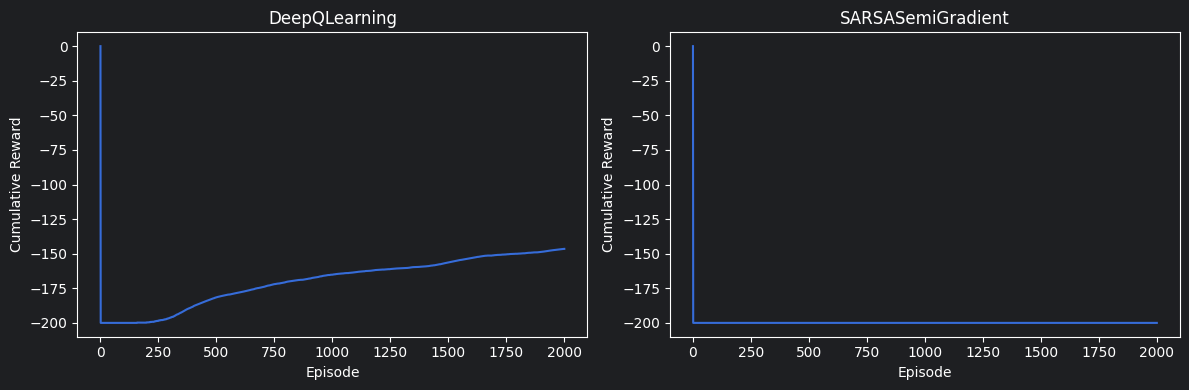

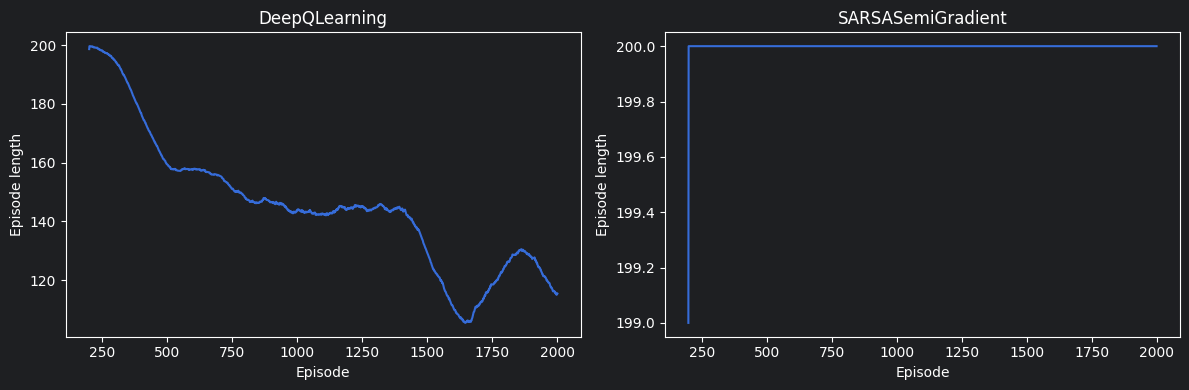

In [17]:
key = (0.997, 0.99, 0.0005) # Mejores parámetros para mejor resultado global de Deep Q-Learning
plot_agent_rewards(results_stats[key], nrows=1, ncols=2, figsize=(12, 4))
plot_episode_lengths_for_agents(results_episode_lengths[key], nrows=1, ncols=2, avg_window=200, figsize=(12, 4))

Observamos las gráficas para Sarsa Semi-Gradient, donde hemos modificado también el tamaño de la ventana deslizante para mostrar la longitud de los episodios completados.

En este caso, vemos como la recompensa acumulada también sube, lo que significa que el agente va aprendiendo poco a poco como resolver el problema de forma más óptima.

En el caso de la gráfica de longitud por episodio, vemos como desciende de forma menos acentuada pero sí más consistente que con Deep Q-Learning, dando a entender que realiza un aprendizaje más estable y predecible que el agente anterior, llegando a unos 110 pasos en su mínimo. Probablemente, si Deep Q-Learning no hubiera tenido esa subida repentina, hubiera mejorado también el resultado global de SARSA en este apartado.

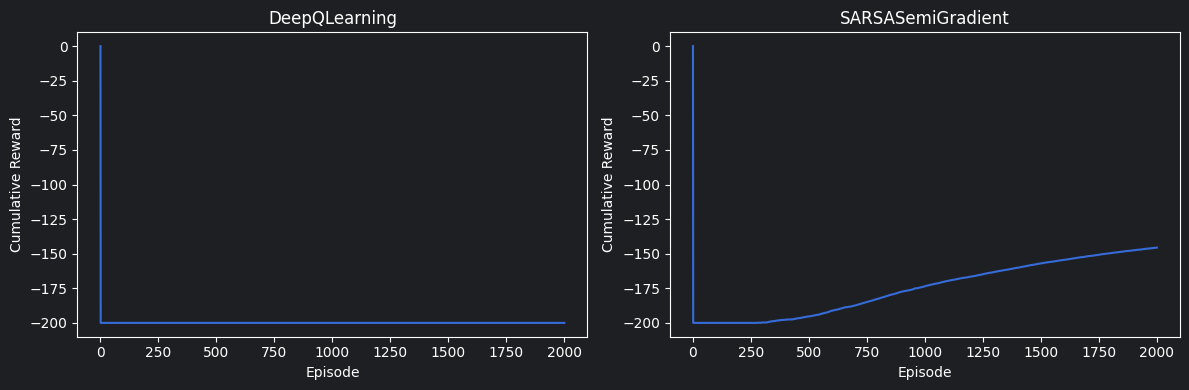

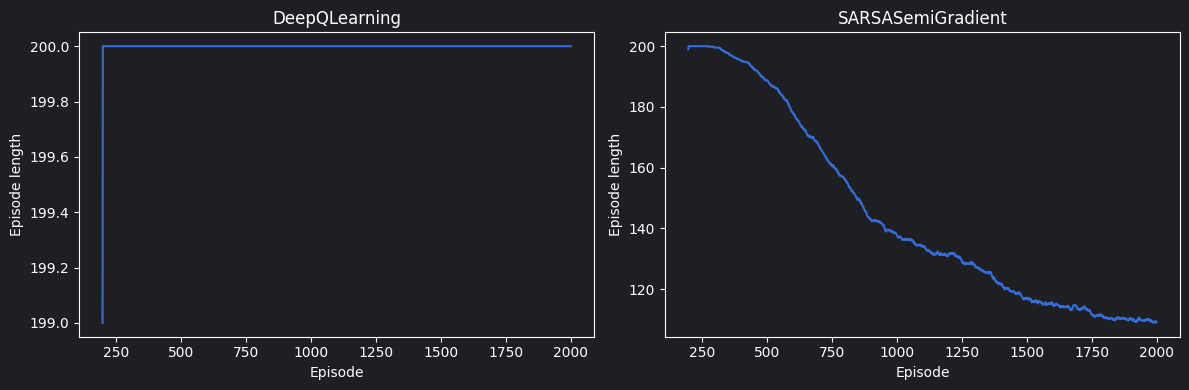

In [18]:
key = (0.997, 0.99, 0.05) # Mejores parámetros para mejor resultado global de SARSA Semi-gradient
plot_agent_rewards(results_stats[key], nrows=1, ncols=2, figsize=(12, 4))
plot_episode_lengths_for_agents(results_episode_lengths[key], nrows=1, ncols=2, avg_window=200, figsize=(12, 4))

### Visualización de resolución del entorno

Vamos a proceder a la generación de dos gifs para SARSA Semi-Gradient y para Deep Q-Learning de la resolución de este entorno. Para ello, vamos a volver a entrenar y quedarnos con la instancia de los modelos para los mejores parámetros, ya que en el entrenamiento original no guardábamos una copia de cada uno.

In [27]:
sarsa_semi_gradient = SARSASemiGradient(tile_coded_env, 1.0, discount_factor=0.99, learning_rate=0.05,
                                        random_seed=random_seed, decay_factor=0.997)

deep_qlearning = DeepQLearning(adapted_reward_env, 1.0, discount_factor=0.99, learning_rate=0.0005,
                               random_seed=random_seed, epsilon_decay=True, decay_factor=0.997)

# Entrenamos estos agentes con su entorno y el número de episodios definidos
_ = run_agent(deep_qlearning, adapted_reward_env, num_episodes)
_ = run_agent(sarsa_semi_gradient, tile_coded_env, num_episodes)



 10%|█         | 204/2000 [00:11<01:42, 17.57it/s]

success: -200.65, epsilon: 0.5466719878103016


 20%|██        | 404/2000 [00:21<01:10, 22.80it/s]

success: -188.39, epsilon: 0.2997495107888329


 30%|███       | 605/2000 [00:30<01:05, 21.35it/s]

...

 81%|████████  | 1624/2000 [00:12<00:02, 160.91it/s]

success: -154.79625, epsilon: 0.01


 92%|█████████▏| 1833/2000 [00:14<00:00, 174.76it/s]

success: -150.07055555555556, epsilon: 0.01


100%|██████████| 2000/2000 [00:15<00:00, 131.44it/s]


Definimos la función necesaria para obtener los frames a lo largo de la ejecución en un episodio ya entrenado, utilizando el método de gymnasium `env.render()`. Esta función será llamada `get_episode_frames`. Definimos también la función `frames_to_gif` para conformar y guardar un archivo .gif con esos frames.


In [31]:
def get_episode_frames(agent, env, max_steps=200):
    """
    Ejecuta un episodio y obtiene los frames gráficos correspondientes para un agente
    y un entorno. Devuelve esa lista de frames
    """
    episode_frames = []  # Lista para almacenar cada fotograma.
    state, _ = env.reset()
    done = False  # Indicador de finalización del episodio.
    # Ejecutar el episodio hasta max_steps o hasta que el entorno indique que ha terminado.
    for _ in range(max_steps):
        frame = env.render() # Capturar el fotograma actual del entorno
        episode_frames.append(frame)
        action =  agent.get_action(state)

        next_state, reward, done, truncated, info = env.step(action)
        state = next_state  # Actualizar el estado.
        # Si el episodio ha terminado o se ha truncado, capturar el fotograma final y salir
        if done or truncated:
            episode_frames.append(env.render())
            break

    return episode_frames

def frames_to_gif(episode_frames, filename="mountain_car.gif"):
    """
    Crea un archivo GIF a partir de una lista de fotogramas
    # Abrir un escritor de GIF con imageio
    """
    with imageio.get_writer(filename, mode='I') as writer:
        # Agregar cada fotograma al GIF.
        for frame in episode_frames:
            writer.append_data(frame)
    return filename

def display_gif(gif_path):
    """
    Muestra un GIF incrustado en un objeto html
    """
    with open(gif_path, 'rb') as f:
        video = f.read()
    b64 = base64.b64encode(video) # Convierte el gif a base64
    return HTML(f'<img src="data:image/gif;base64,{b64.decode()}" />')

Obtenemos los frames y generamos el gif para SARSA. Podemos ver como el coche se balancea para lograr adquirir una inercia suficiente hasta subir por la colina y llegar al objetivo.


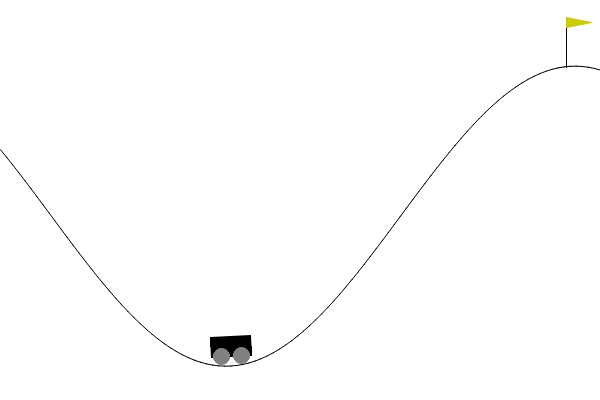

In [34]:
frames = get_episode_frames(sarsa_semi_gradient, tile_coded_env)
gif_path = frames_to_gif(frames, filename="mountain_car_sarsa_semigradient.gif")
display_gif("mountain_car_sarsa_semigradient.gif")

Obtenemos los frames y generamos el gif para Deep Q-Learning. Podemos ver un comportamiento del coche similar al del caso anterior.


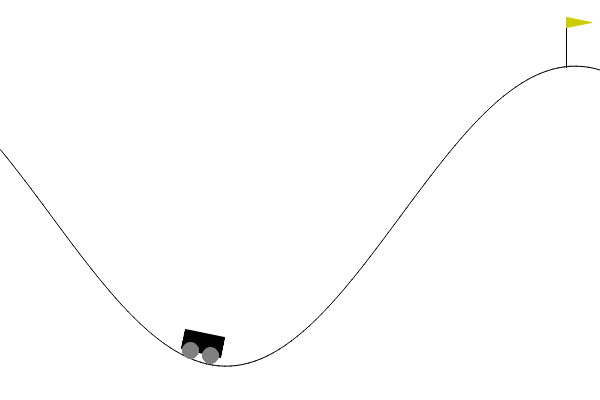

In [33]:
frames = get_episode_frames(deep_qlearning, adapted_reward_env)
gif_path = frames_to_gif(frames, filename="mountain_car_deep_qlearning.gif")
display_gif("mountain_car_deep_qlearning.gif")


## **4. Análisis y Estudios Futuros**

En este estudio se ha podido comprobar como los distintos tipos de agentes que utilizan aprendizaje por refuerzo, y funciones que calculan valores de retorno aproximado han resultado ser efectivos para la resolución del entorno de Mountain Car. A continuación, exponemos una serie de puntos que consiguen englobar lo visto y comentado en apartados anteriores.

### **4.1 Análisis de Resultados**

- **SARSA Semi-gradient**, si bien ha sido el agente más sencillo en cuanto a funcionamiento e implementación, también ha mostrado ser muy efectivo en la resolución de este problema, funcionando de forma más consistente que Deep Q-Learning, al menos en cuanto a reducción de la longitud de los episodios se refiere. Al ser más consistente, también nos ha dado un promedio de longitud por episodio completado menor, de **130 pasos** en promedio. Ha requerido discretizar el espacio de estados utilizando la técnica de _Tile Encoding_.

- **Deep Q-Learning** es más complejo que SARSA y lento de entrenar, dado que utiliza dos redes neuronales. También presenta una serie de ventajas, como que no requiere discretizar el espacio de estados, sino que es capaz de trabajar con variables continuas, pero es por contra mucho más sensible, por ejemplo a los valores de las recompensas. Debido a esto, ha sido necesario declarar un _wrapper_ que modificase la recompensa original del entorno por otra que tuviera en cuenta las componentes de posición y velocidad. En esencia, este modelo ha demostrado tener una potencia considerable, logrando identificar como resolver el problema en apenas **299 episodios**, para solucionarlo correctamente en otros **1701**, como hemos mostrado en los resultados globales.

- La búsqueda de hiperparámetros ha resultado ser efectiva para optimizar el funcionamiento de los agentes:
  - El valor para la **tasa de aprendizaje** se ha mostrado como crítico para que el agente logre resolver o no resolver el problema. Valores pequeños, como 0.0005, son mucho más acordes para una red neuronal, y valores más grandes, como 0.05, funcionan mucho mejor para SARSA Semi-Gradient. Este es un parámetro determinante y es aconsejable dedicar tiempo a buscar el valor óptimo para cada agente y problema.

  - Un factor de **descuento del retorno futuro** de 0.99 también ha resultado ser más adecuando en este problema que un factor de 0.9, lo que significa que, para este entorno en particular, interesa más que en agente tenga en cuenta el futuro a medio plazo que el futuro inmediato de cara a realizar el aprendizaje.

  - También se ha podido comprobar como un factor de decaimiento moderado, como 0.997, funciona mejor que un factor de 0.999 para epsilon decay, haciendo que epsilon decaiga de manera más acentuada conforme al transcurso de los episodios, y se vaya reduciendo por tanto antes la capacidad exploratoria del agente.

- La designación de un conjunto rico de recompensas, en este caso, para Deep Q-learning, ha resultado una vez más mostrarse como positiva y recomendable cuando se tiene un entorno que, si bien no sea trivial, presente cierta dificultad como el que tenemos entre manos.


### **4.2 Propuestas para Estudios Futuros**

- Se podría ampliar el número de episodios en el que se entrenan los agentes para comprobar cómo evolucionan y si cambian los resultados globales que se obtienen.

- Se podría probar con la variante de este entorno, **MountainCarContinuous** que presenta, no solo un conjunto de estados compuesto por componentes continuas, sino un conjunto de acciones contínuo. Sería interesente ver cómo se desempeñan SARSA Semi-gradient (discretizando también acciones) y Deep Q-Learning en ese entorno, que seguramente presentará una dificultad añadida.

- Sería interesante investigar más a fondo ese incremento en la longitud del episodio que ha experimentado Deep Q-Learning hacia el final del entrenamiento, para ver por qué se ha producido e intentar mitigarlo.

- Como optimización, se podría configurar la ejecución de pytorch en la GPU para optimizar el tiempo de entrenamiento de la red neuronal, pero esto depende del hardware donde realicemos las pruebas.